In [1]:
#conda activate burnseverity
import pandas as pd
import geopandas as gpd
import requests
import rasterio as rio
from matplotlib import pyplot as plt
from rasterio.plot import show_hist
import numpy as np
from rasterio.warp import calculate_default_transform, reproject, Resampling
import validation as val



### Validation goals

#### Questions
1. Difference between our dNBR and dNBR from BAIR?
2. Are the two different indices truly different in our tool and is ours truly more sensitive?
3. Do our boundaries and those from CalFire match?
4. Sensitivity around chosen time windows?

#### Metrics
1. Recoarse Sentinel to Landsat, $R^2$
2. $var(dNBR) < var(RBR)$
3. Percent overlap
4. Before period fixed through three weeks. After ${5, 10, 15, 21, 30, 45, 60, 90}$. Criteria: stable and low variance 


In [ ]:
fires = pd.read_csv('fire_processing_jobs.csv')
calfire = gpd.read_file('Validation_Fire_Perimeters_2015_2024.shp')
fire_name = 'COFFEE POT'
fire_days = 5
fire_polygon = calfire[calfire['FIRE_NAME'] == fire_name].to_crs(epsg=4326)

{'fire_event_name': 'COFFEE POT_2024-08-03_5', 'status': 'complete', 'job_id': '573421be-412c-403d-9d72-b591de886c43', 'coarse_severity_cog_urls': {'rbr': 'https://storage.googleapis.com/fire-recovery-store/assets/573421be-412c-403d-9d72-b591de886c43/fire_severity/rbr.tif', 'dnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/573421be-412c-403d-9d72-b591de886c43/fire_severity/dnbr.tif', 'rdnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/573421be-412c-403d-9d72-b591de886c43/fire_severity/rdnbr.tif'}}


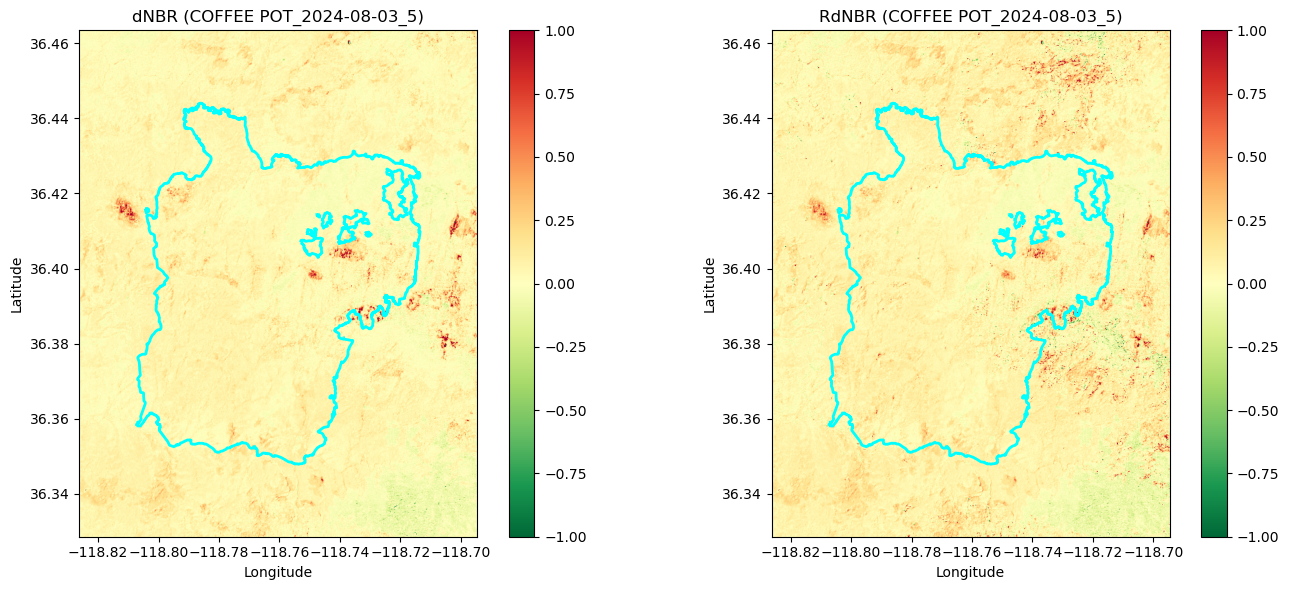

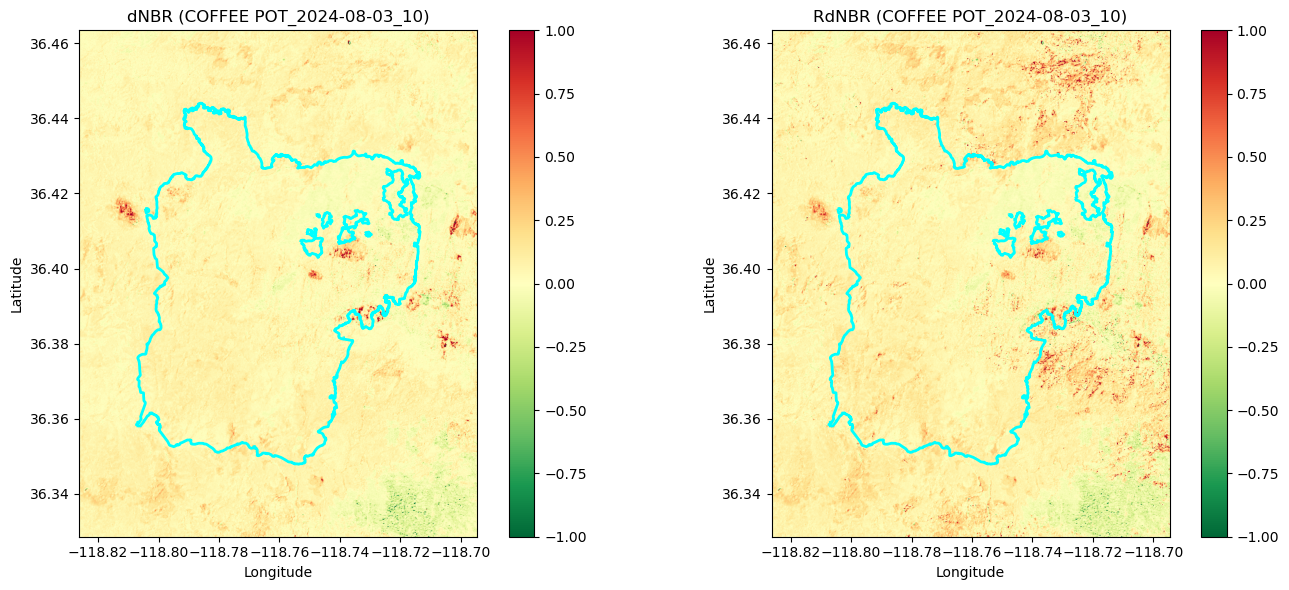

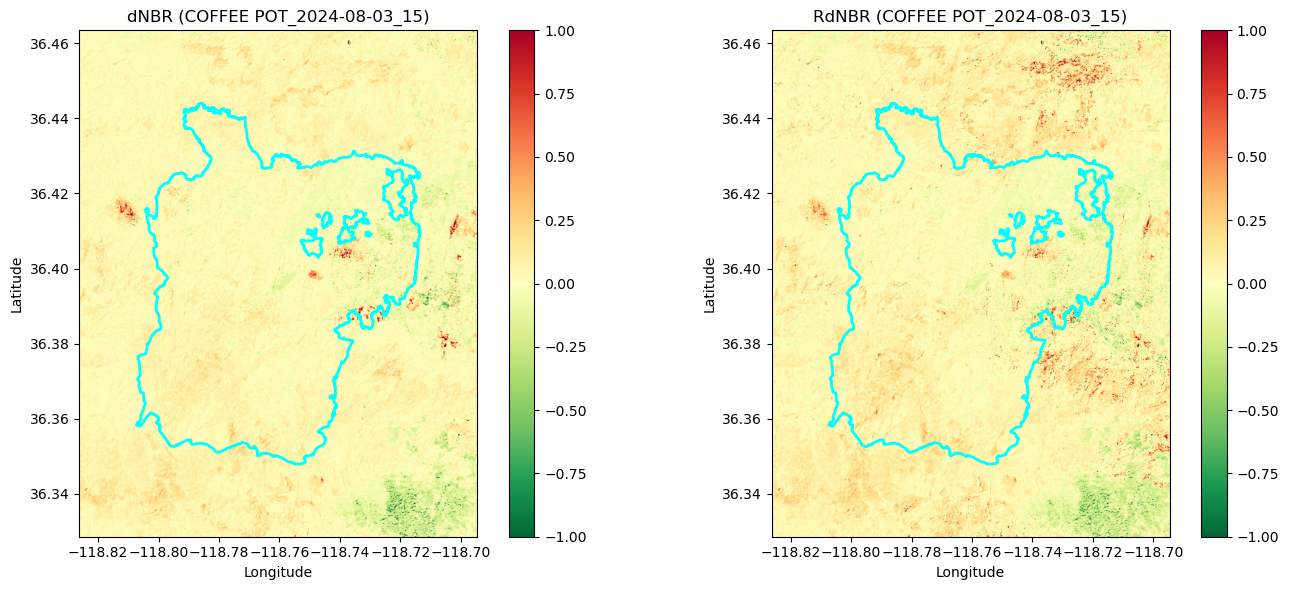

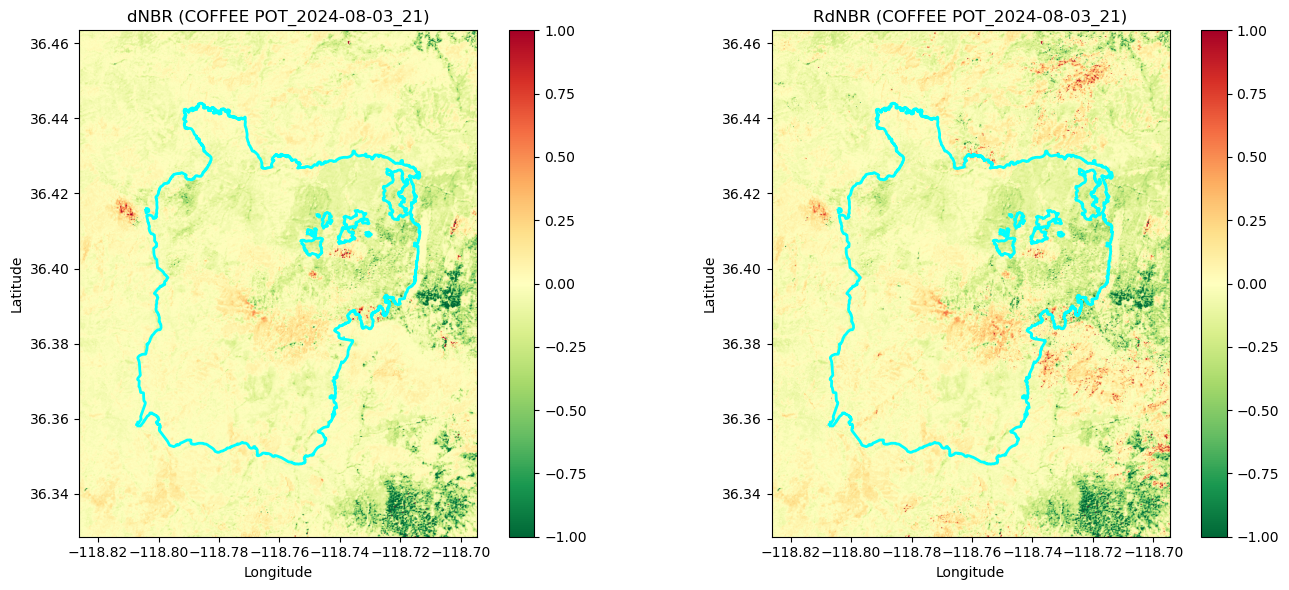

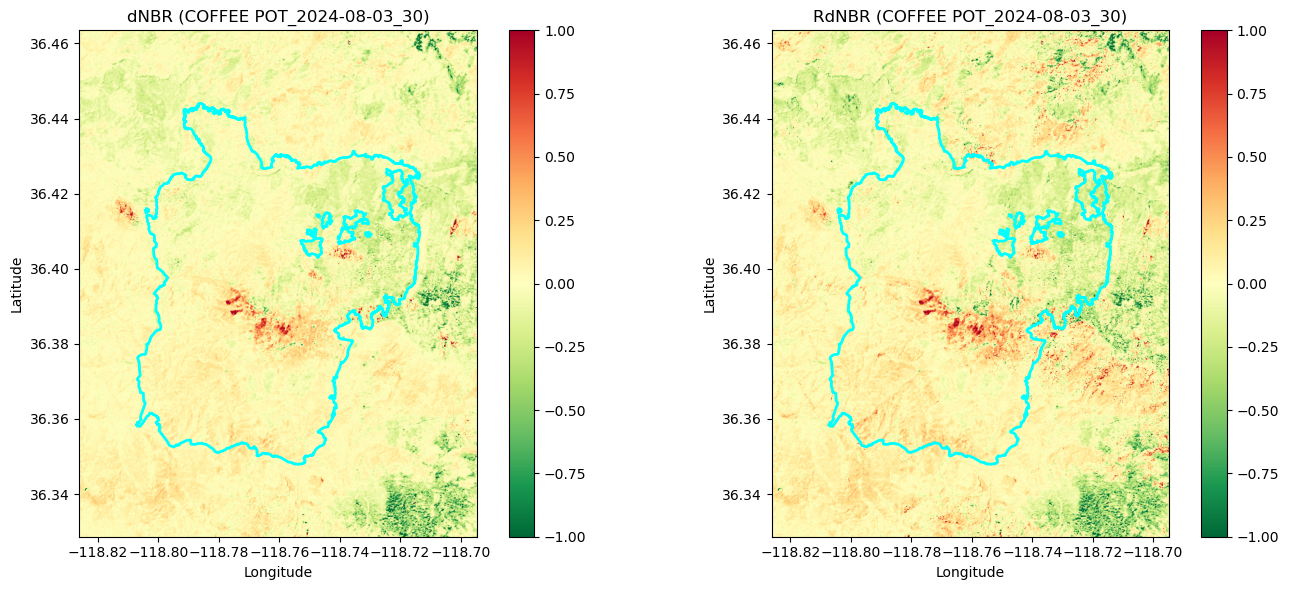

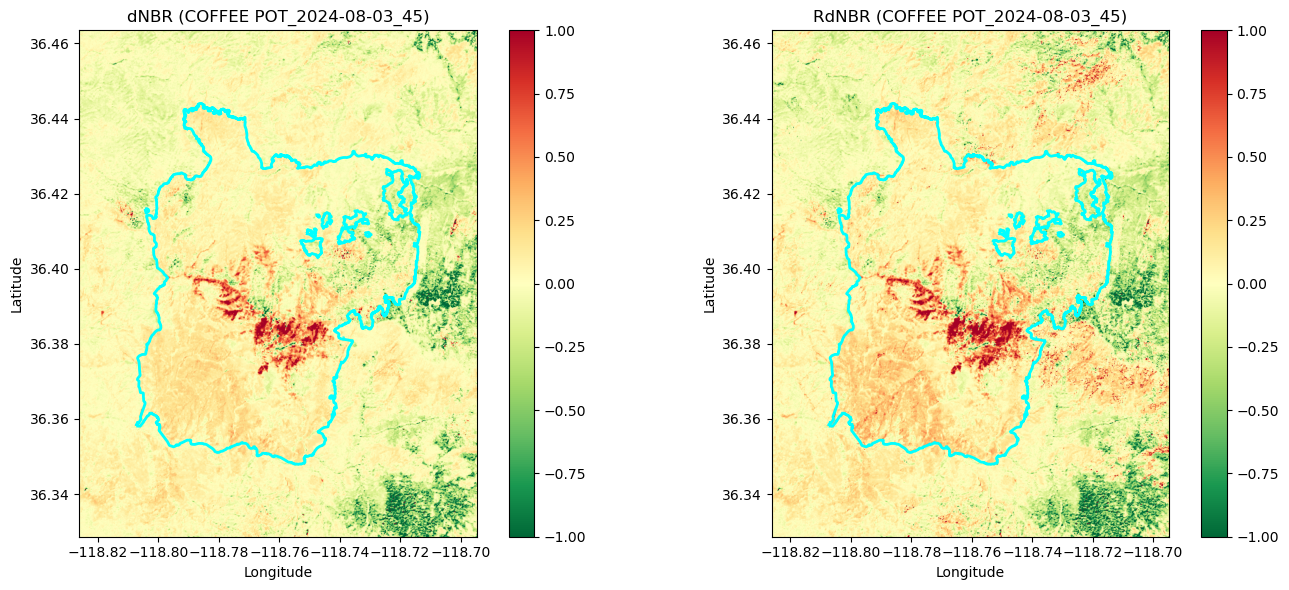

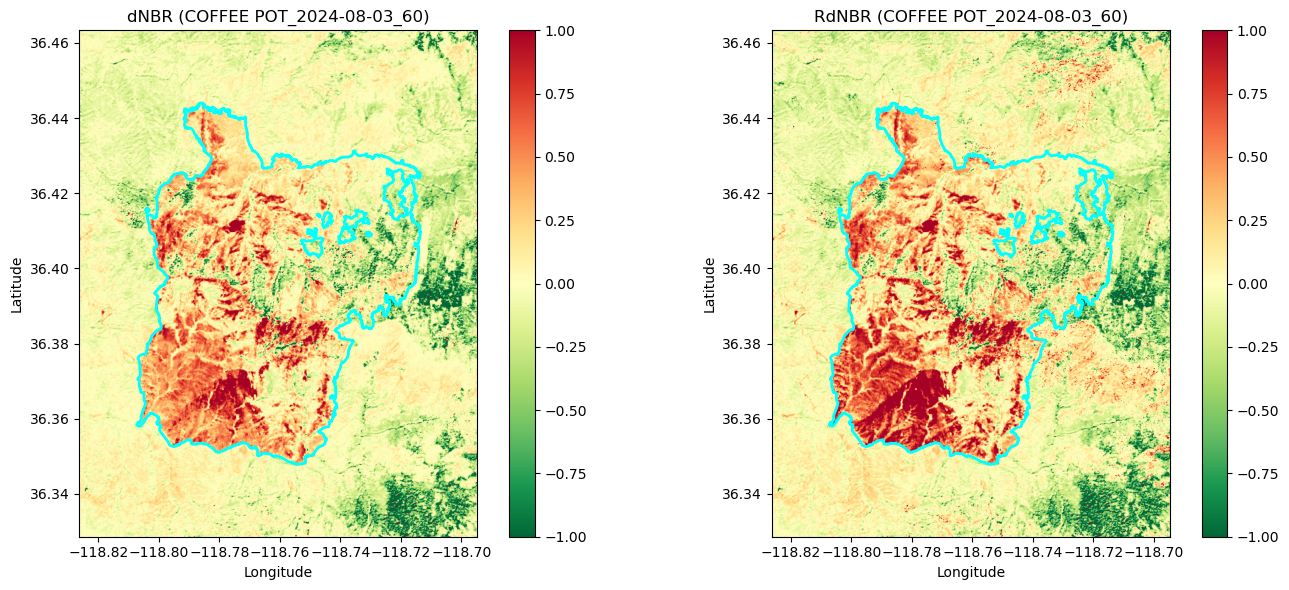

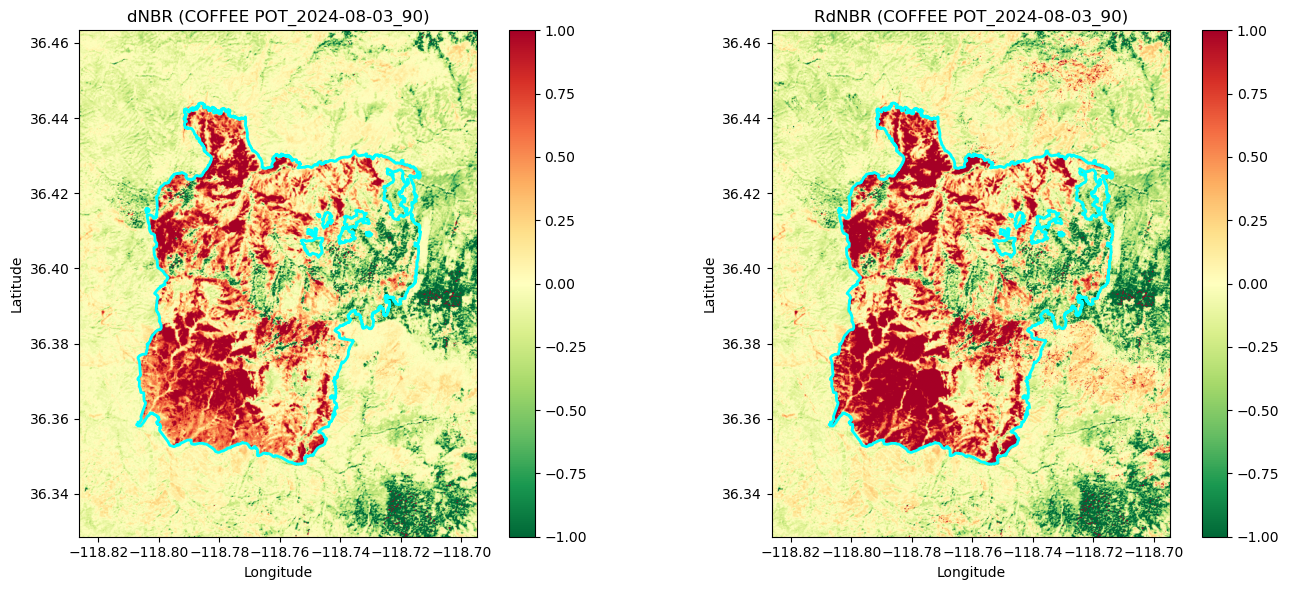

In [4]:
for fire_days in [5, 10, 15, 21, 30, 45, 60, 90]:
    val.plot_fire(fire_name, fire_days, fire_polygon, fires)